In [ ]:
"""
=============================================================
  Mutual Information - Reusable Feature Relevance Utility
=============================================================
Works for:
  - Classification tasks
  - Regression tasks
  - Mixed feature types (numerical + categorical)
  - Pandas DataFrames directly
=============================================================
"""



'\n=============================================================\n  Mutual Information - Reusable Feature Relevance Utility\n=============================================================\nWorks for:\n  - Classification tasks\n  - Regression tasks\n  - Mixed feature types (numerical + categorical)\n  - Pandas DataFrames directly\n=============================================================\n'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder




In [ ]:
# ─────────────────────────────────────────────
# 1. CORE FUNCTION
# ─────────────────────────────────────────────

def compute_mutual_information(
    df: pd.DataFrame,
    target_col: str,
    task: str = "classification",
    discrete_features: list = None,
    n_neighbors: int = 3,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Compute Mutual Information scores for all features vs target.

    Parameters
    ----------
    df               : Input DataFrame (features + target)
    target_col       : Name of the target column
    task             : "classification" or "regression"
    discrete_features: List of column names that are discrete/categorical.
                       If None, auto-detects based on dtype.
    n_neighbors      : Number of neighbors for MI estimation (for continuous features)
    random_state     : Seed for reproducibility

    Returns
    -------
    pd.DataFrame with columns: ['Feature', 'MI_Score', 'Normalized_MI', 'Rank']
    """

    df = df.copy()

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Encode target if classification and it's categorical
    if task == "classification" and y.dtype == "object":
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Encode categorical feature columns as numeric
    for col in X.select_dtypes(include=["object", "category"]).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Auto-detect discrete features if not provided
    if discrete_features is None:
        discrete_mask = [
            X[col].dtype in [np.int32, np.int64] or X[col].nunique() <= 10
            for col in X.columns
        ]
    else:
        discrete_mask = [col in discrete_features for col in X.columns]

    # Compute MI scores
    if task == "classification":
        mi_scores = mutual_info_classif(
            X, y,
            discrete_features=discrete_mask,
            n_neighbors=n_neighbors,
            random_state=random_state
        )
    elif task == "regression":
        mi_scores = mutual_info_regression(
            X, y,
            discrete_features=discrete_mask,
            n_neighbors=n_neighbors,
            random_state=random_state
        )
    else:
        raise ValueError("task must be 'classification' or 'regression'")

    # Build result DataFrame
    mi_df = pd.DataFrame({
        "Feature": X.columns,
        "MI_Score": mi_scores
    })

    # Normalize MI scores to 0-1 range
    max_score = mi_df["MI_Score"].max()
    mi_df["Normalized_MI"] = mi_df["MI_Score"] / max_score if max_score > 0 else 0

    # Rank features (1 = most relevant)
    mi_df = mi_df.sort_values("MI_Score", ascending=False).reset_index(drop=True)
    mi_df["Rank"] = mi_df.index + 1

    return mi_df



In [ ]:

# ─────────────────────────────────────────────
# 2. SELECT TOP N FEATURES
# ─────────────────────────────────────────────

def select_top_features(
    mi_df: pd.DataFrame,
    top_n: int = 10,
    threshold: float = None
) -> list:
    """
    Select top N features or features above a MI threshold.

    Parameters
    ----------
    mi_df     : Output from compute_mutual_information()
    top_n     : Number of top features to select
    threshold : Minimum MI score to keep (overrides top_n if provided)

    Returns
    -------
    List of selected feature names
    """
    if threshold is not None:
        selected = mi_df[mi_df["MI_Score"] >= threshold]["Feature"].tolist()
    else:
        selected = mi_df.head(top_n)["Feature"].tolist()

    print(f"\n✅ Selected {len(selected)} features:")
    for i, feat in enumerate(selected, 1):
        score = mi_df[mi_df["Feature"] == feat]["MI_Score"].values[0]
        print(f"   {i}. {feat}  →  MI Score: {score:.4f}")

    return selected




In [ ]:
# ─────────────────────────────────────────────
# 3. PLOT MI SCORES
# ─────────────────────────────────────────────

def plot_mutual_information(
    mi_df: pd.DataFrame,
    top_n: int = 20,
    title: str = "Mutual Information Scores",
    color: str = "steelblue",
    figsize: tuple = (10, 6)
):
    """
    Plot a horizontal bar chart of MI scores.

    Parameters
    ----------
    mi_df   : Output from compute_mutual_information()
    top_n   : How many top features to show in chart
    title   : Chart title
    color   : Bar color
    figsize : Figure size
    """
    plot_df = mi_df.head(top_n).sort_values("MI_Score", ascending=True)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(plot_df["Feature"], plot_df["MI_Score"], color=color, edgecolor="white")

    # Add value labels on bars
    for bar, val in zip(bars, plot_df["MI_Score"]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel("Mutual Information Score", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()




In [ ]:
# ─────────────────────────────────────────────
# 4. MI HEATMAP (feature vs feature)
# ─────────────────────────────────────────────

def plot_mi_heatmap(
    df: pd.DataFrame,
    cols: list = None,
    figsize: tuple = (12, 10),
    title: str = "Mutual Information Heatmap (Feature vs Feature)"
):
    """
    Plot MI between every pair of features as a heatmap.
    Useful to detect redundant features.

    Parameters
    ----------
    df     : Input DataFrame
    cols   : Specific columns to include (None = all numeric columns)
    figsize: Figure size
    title  : Chart title
    """
    df = df.copy()

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    df_sub = df[cols].copy()

    # Encode any remaining categoricals
    for col in df_sub.select_dtypes(include=["object", "category"]).columns:
        le = LabelEncoder()
        df_sub[col] = le.fit_transform(df_sub[col].astype(str))

    n = len(cols)
    mi_matrix = np.zeros((n, n))

    for i, col_i in enumerate(cols):
        discrete_mask = [
            df_sub[c].nunique() <= 10 for c in cols
        ]
        mi_scores = mutual_info_regression(
            df_sub, df_sub[col_i],
            discrete_features=discrete_mask
        )
        mi_matrix[i] = mi_scores

    mi_matrix_df = pd.DataFrame(mi_matrix, index=cols, columns=cols)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        mi_matrix_df, annot=True, fmt=".2f",
        cmap="YlOrRd", linewidths=0.5,
        ax=ax, cbar_kws={"label": "MI Score"}
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()




In [ ]:
# ─────────────────────────────────────────────
# 5. FULL PIPELINE (one-liner)
# ─────────────────────────────────────────────

def mi_feature_selection_pipeline(
    df: pd.DataFrame,
    target_col: str,
    task: str = "classification",
    top_n: int = 10,
    threshold: float = None,
    plot: bool = True,
    discrete_features: list = None
) -> tuple:
    """
    Full pipeline: compute MI → plot → return top features.

    Parameters
    ----------
    df               : Input DataFrame
    target_col       : Target column name
    task             : "classification" or "regression"
    top_n            : Number of top features to select
    threshold        : MI score threshold (overrides top_n if set)
    plot             : Whether to show the bar chart
    discrete_features: List of discrete/categorical column names

    Returns
    -------
    (mi_df, selected_features)
      mi_df             → Full MI scores DataFrame
      selected_features → List of top feature names
    """
    print(f"📊 Computing Mutual Information ({task})...")
    mi_df = compute_mutual_information(df, target_col, task, discrete_features)

    print("\n📋 Top Features by MI Score:")
    print(mi_df.head(top_n).to_string(index=False))

    if plot:
        plot_mutual_information(
            mi_df, top_n=top_n,
            title=f"Mutual Information Scores — {target_col} ({task})"
        )

    selected = select_top_features(mi_df, top_n=top_n, threshold=threshold)

    return mi_df, selected




📊 Computing Mutual Information (classification)...

📋 Top Features by MI Score:
             Feature  MI_Score  Normalized_MI  Rank
     worst perimeter  0.471842       1.000000     1
          worst area  0.464313       0.984043     2
        worst radius  0.451230       0.956315     3
 mean concave points  0.438806       0.929985     4
worst concave points  0.436255       0.924578     5
      mean perimeter  0.402361       0.852744     6
      mean concavity  0.375447       0.795704     7
         mean radius  0.362276       0.767790     8
           mean area  0.360023       0.763016     9
          area error  0.340759       0.722188    10


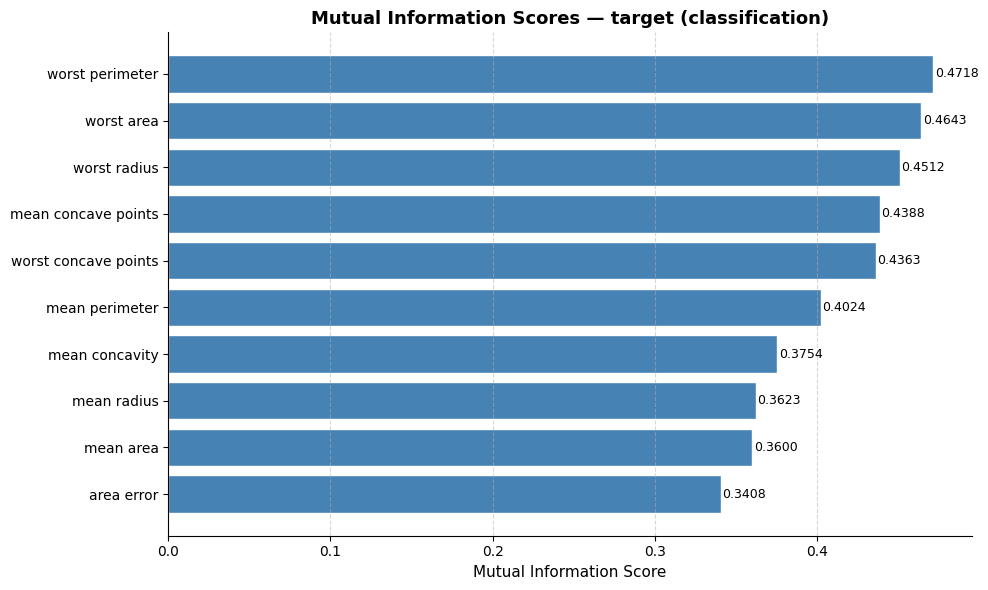


✅ Selected 10 features:
   1. worst perimeter  →  MI Score: 0.4718
   2. worst area  →  MI Score: 0.4643
   3. worst radius  →  MI Score: 0.4512
   4. mean concave points  →  MI Score: 0.4388
   5. worst concave points  →  MI Score: 0.4363
   6. mean perimeter  →  MI Score: 0.4024
   7. mean concavity  →  MI Score: 0.3754
   8. mean radius  →  MI Score: 0.3623
   9. mean area  →  MI Score: 0.3600
   10. area error  →  MI Score: 0.3408

🔢 Shape of selected feature set: (569, 10)


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


HTTPError: HTTP Error 403: Forbidden

In [ ]:
# ─────────────────────────────────────────────
# EXAMPLE USAGE
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # ── Example 1: Classification (e.g., stock up/down prediction) ──
    from sklearn.datasets import load_breast_cancer

    data = load_breast_cancer(as_frame=True)
    df_clf = data.frame

    mi_df, top_features = mi_feature_selection_pipeline(
        df=df_clf,
        target_col="target",
        task="classification",
        top_n=10,
        plot=True
    )

    # Use selected features for model training
    X_selected = df_clf[top_features]
    print(f"\n🔢 Shape of selected feature set: {X_selected.shape}")


    # ── Example 2: Regression (e.g., Nifty price prediction) ──
    from sklearn.datasets import fetch_california_housing

    data2 = fetch_california_housing(as_frame=True)
    df_reg = data2.frame

    mi_df_reg, top_features_reg = mi_feature_selection_pipeline(
        df=df_reg,
        target_col="MedHouseVal",
        task="regression",
        top_n=5,
        plot=True
    )


    # ── Example 3: Use threshold instead of top_n ──
    mi_df2, features_thresh = mi_feature_selection_pipeline(
        df=df_clf,
        target_col="target",
        task="classification",
        threshold=0.1,    # only features with MI >= 0.1
        plot=False
    )

### New Example 2: Regression with Diabetes Dataset

This example uses the `load_diabetes` dataset for a regression task, demonstrating how to compute mutual information for predicting disease progression.

📊 Computing Mutual Information (regression)...

📋 Top Features by MI Score:
Feature  MI_Score  Normalized_MI  Rank
    bmi  0.175691       1.000000     1
     s5  0.145826       0.830012     2
     s6  0.117211       0.667144     3
     s4  0.107586       0.612357     4
     s3  0.070815       0.403064     5


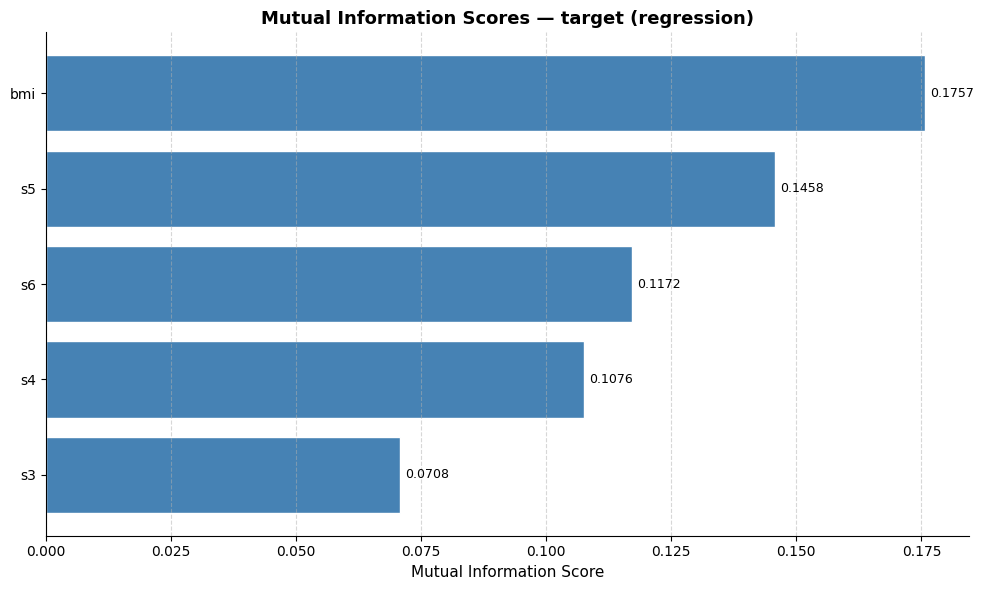


✅ Selected 5 features:
   1. bmi  →  MI Score: 0.1757
   2. s5  →  MI Score: 0.1458
   3. s6  →  MI Score: 0.1172
   4. s4  →  MI Score: 0.1076
   5. s3  →  MI Score: 0.0708

🔢 Shape of selected feature set (Diabetes): (442, 5)


In [ ]:
from sklearn.datasets import load_diabetes

data_diabetes = load_diabetes(as_frame=True)
df_diabetes = data_diabetes.frame

mi_df_diabetes, top_features_diabetes = mi_feature_selection_pipeline(
    df=df_diabetes,
    target_col="target",
    task="regression",
    top_n=5,
    plot=True
)
print(f"\n🔢 Shape of selected feature set (Diabetes): {df_diabetes[top_features_diabetes].shape}")

### New Example 3: Classification with Wine Dataset

This example uses the `load_wine` dataset for a classification task, demonstrating mutual information to identify features relevant to wine classification.

📊 Computing Mutual Information (classification)...

📋 Top Features by MI Score:
                     Feature  MI_Score  Normalized_MI  Rank
                  flavanoids  0.667602       1.000000     1
                     proline  0.577391       0.864872     2
             color_intensity  0.548274       0.821258     3
od280/od315_of_diluted_wines  0.516158       0.773152     4
                     alcohol  0.474312       0.710471     5
                         hue  0.466412       0.698637     6
               total_phenols  0.401599       0.601554     7


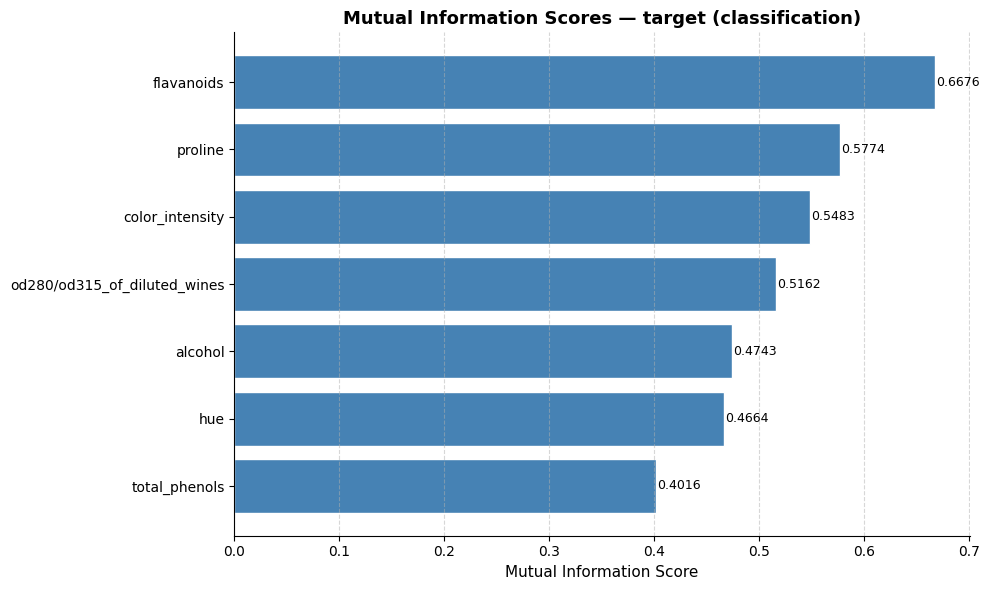


✅ Selected 7 features:
   1. flavanoids  →  MI Score: 0.6676
   2. proline  →  MI Score: 0.5774
   3. color_intensity  →  MI Score: 0.5483
   4. od280/od315_of_diluted_wines  →  MI Score: 0.5162
   5. alcohol  →  MI Score: 0.4743
   6. hue  →  MI Score: 0.4664
   7. total_phenols  →  MI Score: 0.4016

🔢 Shape of selected feature set (Wine): (178, 7)


In [ ]:
from sklearn.datasets import load_wine

data_wine = load_wine(as_frame=True)
df_wine = data_wine.frame

mi_df_wine, top_features_wine = mi_feature_selection_pipeline(
    df=df_wine,
    target_col="target",
    task="classification",
    top_n=7,
    plot=True
)
print(f"\n🔢 Shape of selected feature set (Wine): {df_wine[top_features_wine].shape}")